In [5]:
# ==============================================================================
# Estudo Dirigido 4: Filtros Digitais - Processamento Digital de Sinais (IFPB)
# Aluno: Luiza Bruna Apolinario Ribeiro
# Objetivo: Implementação e análise comparativa entre filtros FIR e IIR.
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Configurações globais de plotagem
plt.style.use('ggplot')

# Definindo parâmetros de simulação
fs = 1000  # Frequência de amostragem
T = 1.0    # Duração (segundos)
t = np.arange(0, T, 1/fs)
nyq = 0.5 * fs # Frequência de Nyquist

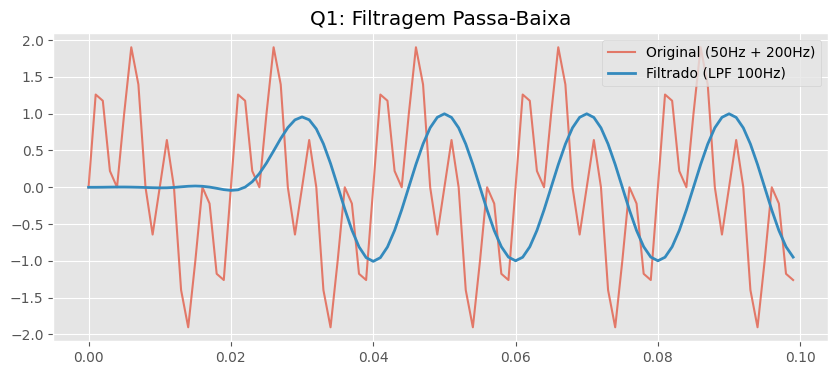

In [6]:
# ---------------------------------------------------------
# Q1: Duas senoides e Filtro Passa-Baixa
# ---------------------------------------------------------
sinal_q1 = np.sin(2 * np.pi * 50 * t) + np.sin(2 * np.pi * 200 * t)
b_fir = signal.firwin(51, 100/nyq) # Filtro passa-baixa FIR
sinal_q1_filtrado = signal.lfilter(b_fir, 1.0, sinal_q1)

plt.figure(figsize=(10, 4))
plt.plot(t[:100], sinal_q1[:100], label='Original (50Hz + 200Hz)', alpha=0.7)
plt.plot(t[:100], sinal_q1_filtrado[:100], label='Filtrado (LPF 100Hz)', linewidth=2)
plt.title("Q1: Filtragem Passa-Baixa")
plt.legend()
plt.show()

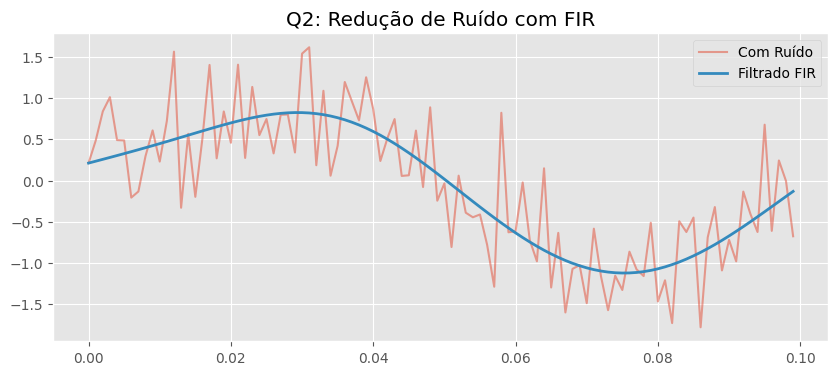

In [7]:
# ---------------------------------------------------------
# Q2: Ruído Branco + Filtro FIR
# ---------------------------------------------------------
sinal_limpo = np.sin(2 * np.pi * 10 * t)
ruido = np.random.normal(0, 0.5, len(t))
sinal_ruidoso = sinal_limpo + ruido

b_fir_q2 = signal.firwin(101, 30/nyq)
sinal_q2_filt = signal.filtfilt(b_fir_q2, 1.0, sinal_ruidoso)

plt.figure(figsize=(10, 4))
plt.plot(t[:100], sinal_ruidoso[:100], label='Com Ruído', alpha=0.5)
plt.plot(t[:100], sinal_q2_filt[:100], label='Filtrado FIR', linewidth=2)
plt.title("Q2: Redução de Ruído com FIR")
plt.legend()
plt.show()

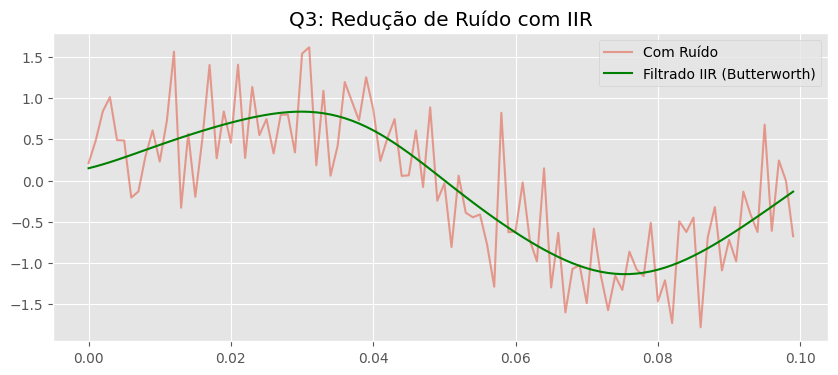

In [8]:
# ---------------------------------------------------------
# Q3: Ruído Branco + Filtro IIR Butterworth
# ---------------------------------------------------------
b_iir, a_iir = signal.butter(4, 30/nyq, btype='low')
sinal_q3_filt = signal.filtfilt(b_iir, a_iir, sinal_ruidoso)

plt.figure(figsize=(10, 4))
plt.plot(t[:100], sinal_ruidoso[:100], label='Com Ruído', alpha=0.5)
plt.plot(t[:100], sinal_q3_filt[:100], label='Filtrado IIR (Butterworth)', color='green')
plt.title("Q3: Redução de Ruído com IIR")
plt.legend()
plt.show()

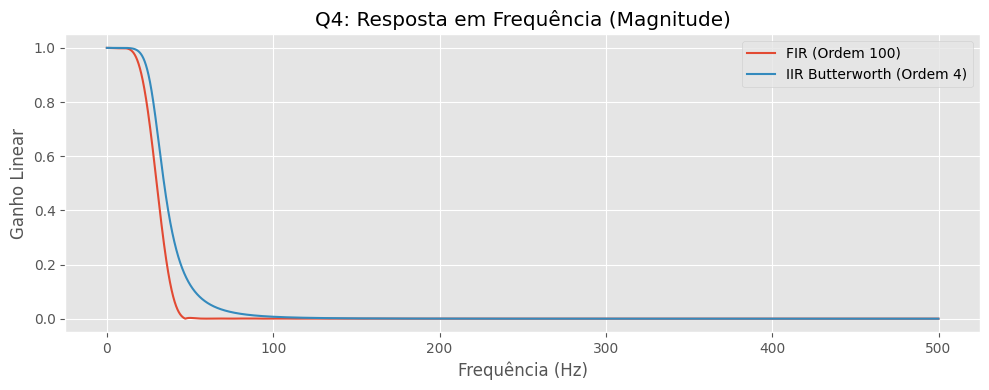

In [10]:
# =====================================================================
# Q4. Comparação Resposta em Frequência (FIR e IIR)
# =====================================================================
b_fir_noise = signal.firwin(101, 30/nyq)
w_fir, h_fir = signal.freqz(b_fir_noise, 1.0, worN=8000)
w_iir, h_iir = signal.freqz(b_iir, a_iir, worN=8000)

plt.figure(figsize=(10, 4))
plt.plot(0.5 * fs * w_fir / np.pi, np.abs(h_fir), label='FIR (Ordem 100)')
plt.plot(0.5 * fs * w_iir / np.pi, np.abs(h_iir), label='IIR Butterworth (Ordem 4)')
plt.title('Q4: Resposta em Frequência (Magnitude)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Ganho Linear')
plt.legend()
plt.tight_layout()
plt.savefig('q4_resposta_frequencia.png')

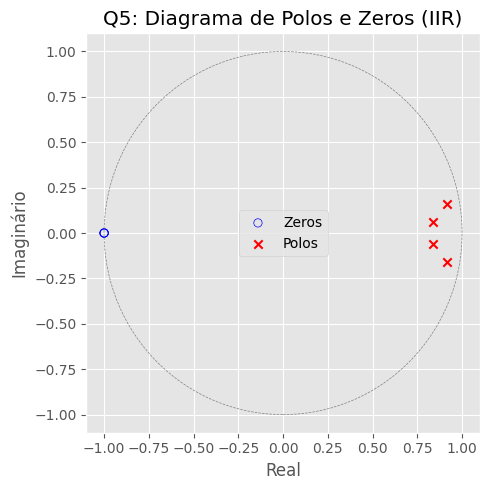

In [11]:
# =====================================================================
# Q5. Polos e Zeros do IIR
# =====================================================================
z, p, k = signal.tf2zpk(b_iir, a_iir)
plt.figure(figsize=(5, 5))
plt.scatter(np.real(z), np.imag(z), marker='o', edgecolors='b', facecolors='none', label='Zeros')
plt.scatter(np.real(p), np.imag(p), marker='x', color='r', label='Polos')
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_patch(circle)
plt.title('Q5: Diagrama de Polos e Zeros (IIR)')
plt.xlabel('Real')
plt.ylabel('Imaginário')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('q5_polos_zeros.png')

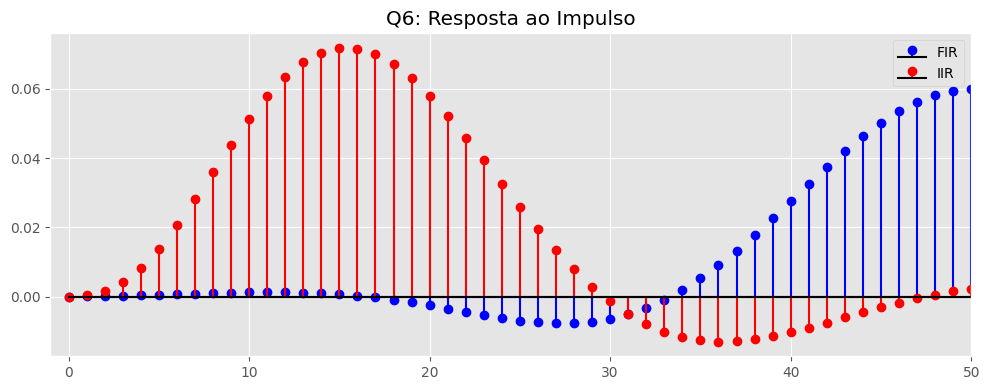

In [12]:
# =====================================================================
# Q6. Resposta ao Impulso (FIR vs IIR)
# =====================================================================
impulse = signal.unit_impulse(100)
impulse_fir = signal.lfilter(b_fir_noise, 1.0, impulse)
impulse_iir = signal.lfilter(b_iir, a_iir, impulse)

plt.figure(figsize=(10, 4))
plt.stem(impulse_fir, linefmt='b-', markerfmt='bo', basefmt='k-', label='FIR')
plt.stem(impulse_iir, linefmt='r-', markerfmt='ro', basefmt='k-', label='IIR')
plt.title('Q6: Resposta ao Impulso')
plt.xlim(-1, 50)
plt.legend()
plt.tight_layout()
plt.savefig('q6_impulso.png')

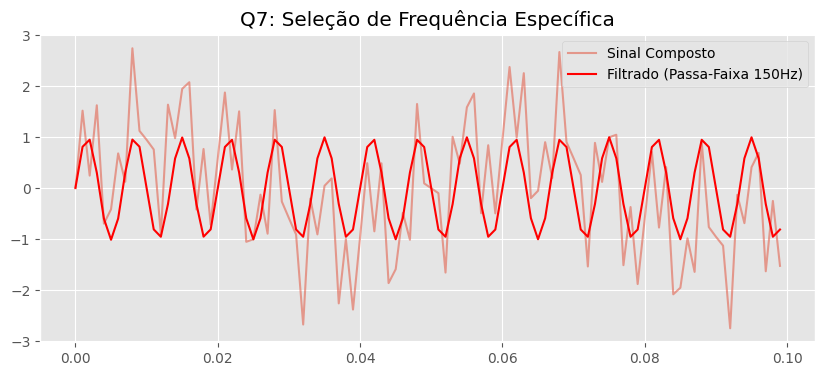

In [13]:
# ---------------------------------------------------------
# Q7: Filtro Passa-Faixa
# ---------------------------------------------------------
# Sinal com 3 componentes: 20Hz, 150Hz, 400Hz
sinal_q7 = np.sin(2*np.pi*20*t) + np.sin(2*np.pi*150*t) + np.sin(2*np.pi*400*t)
# Isolando a componente central (150Hz)
b_bp, a_bp = signal.butter(4, [100/nyq, 200/nyq], btype='band')
sinal_q7_filt = signal.filtfilt(b_bp, a_bp, sinal_q7)

plt.figure(figsize=(10, 4))
plt.plot(t[:100], sinal_q7[:100], label='Sinal Composto', alpha=0.5)
plt.plot(t[:100], sinal_q7_filt[:100], label='Filtrado (Passa-Faixa 150Hz)', color='red')
plt.title("Q7: Seleção de Frequência Específica")
plt.legend()
plt.show()

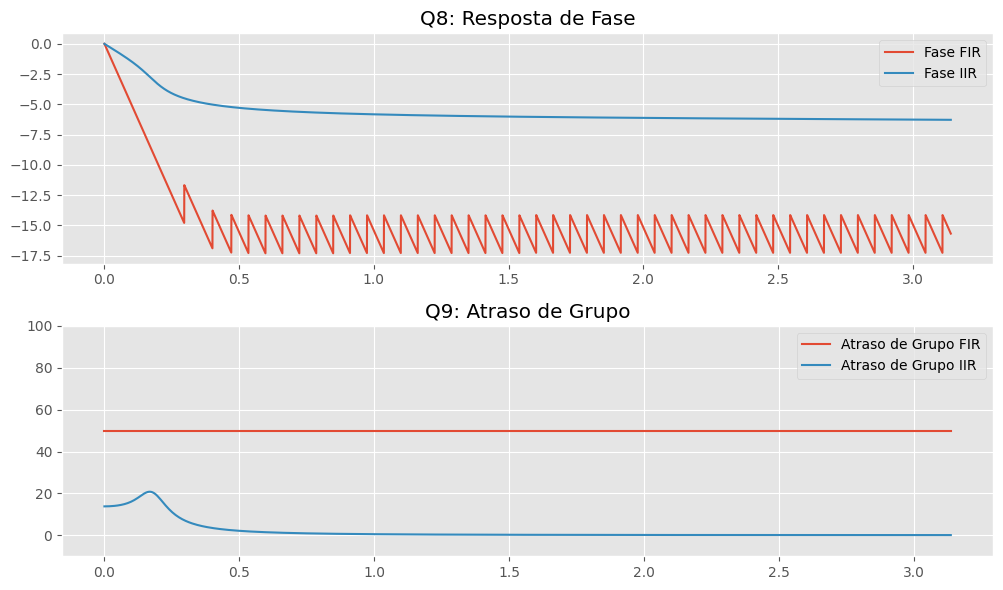

In [14]:
# =====================================================================
# Q8 e Q9. Resposta de Fase e Atraso de Grupo
# =====================================================================
angles_fir = np.unwrap(np.angle(h_fir))
angles_iir = np.unwrap(np.angle(h_iir))

w, gd_fir = signal.group_delay((b_fir_noise, 1.0))
w, gd_iir = signal.group_delay((b_iir, a_iir))

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(w_fir, angles_fir, label='Fase FIR')
plt.plot(w_iir, angles_iir, label='Fase IIR')
plt.title('Q8: Resposta de Fase')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(w, gd_fir, label='Atraso de Grupo FIR')
plt.plot(w, gd_iir, label='Atraso de Grupo IIR')
plt.title('Q9: Atraso de Grupo')
plt.ylim(-10, 100)
plt.legend()
plt.tight_layout()
plt.savefig('q8_q9_fase_atraso.png')

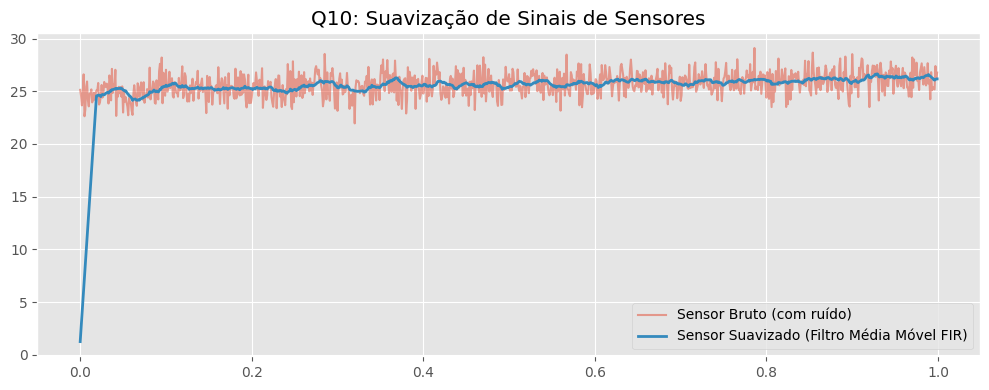

In [15]:
# =====================================================================
# Q10. Aplicação Prática: Suavização de Sensor (Média Móvel)
# =====================================================================
# Simulando a leitura de um sensor de temperatura com picos espúrios
sensor_data = 25 + 2 * np.sin(2 * np.pi * 0.1 * t) + np.random.normal(0, 1, len(t))
window_size = 20
b_mov = np.ones(window_size) / window_size
sensor_smooth = signal.lfilter(b_mov, 1.0, sensor_data)

plt.figure(figsize=(10, 4))
plt.plot(t, sensor_data, label='Sensor Bruto (com ruído)', alpha=0.5)
plt.plot(t, sensor_smooth, label='Sensor Suavizado (Filtro Média Móvel FIR)', linewidth=2)
plt.title('Q10: Suavização de Sinais de Sensores')
plt.legend()
plt.tight_layout()
plt.savefig('q10_sensor.png')